In [1]:
import lightgbm

In [2]:
lightgbm.__version__

'4.6.0'

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
)

import lightgbm as lgb

# AUC - area under the curve, ROC - dependency between TPR and FPR

In [5]:

hr_data = pd.read_csv('../datasets/hr_analytics.csv')

In [6]:
hr_data.head().T

,0,1,2,3,4
employee_id,65438,65141,7513,2542,48945
department,Sales & Marketing,Operations,Sales & Marketing,Sales & Marketing,Technology
region,region_7,region_22,region_19,region_23,region_26
education,Master's & above,Bachelor's,Bachelor's,Bachelor's,Bachelor's
gender,f,m,m,m,m
recruitment_channel,sourcing,other,sourcing,other,other
no_of_trainings,1,1,1,2,1
age,35,30,34,39,45
previous_year_rating,5.0,5.0,3.0,1.0,3.0
length_of_service,8,4,7,10,2


In [7]:
hr_data.shape

(54735, 13)

In [8]:
hr_data.isnull().sum()

employee_id                0
department                 0
region                     0
education               2406
gender                     0
recruitment_channel        0
no_of_trainings            0
age                        0
previous_year_rating    4119
length_of_service          0
awards_won?                0
avg_training_score         0
is_promoted                0
dtype: int64

In [9]:
hr_data = hr_data.drop(columns=['employee_id'], axis=1)

In [10]:
hr_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54735 entries, 0 to 54734
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   department            54735 non-null  object 
 1   region                54735 non-null  object 
 2   education             52329 non-null  object 
 3   gender                54735 non-null  object 
 4   recruitment_channel   54735 non-null  object 
 5   no_of_trainings       54735 non-null  int64  
 6   age                   54735 non-null  int64  
 7   previous_year_rating  50616 non-null  float64
 8   length_of_service     54735 non-null  int64  
 9   awards_won?           54735 non-null  int64  
 10  avg_training_score    54735 non-null  int64  
 11  is_promoted           54735 non-null  int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 5.0+ MB


In [11]:
categorical_features = hr_data.select_dtypes(exclude=np.number).columns.tolist()
categorical_features

['department', 'region', 'education', 'gender', 'recruitment_channel']

In [12]:
hr_data[categorical_features] = hr_data[categorical_features].astype('category')

In [13]:
hr_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54735 entries, 0 to 54734
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   department            54735 non-null  category
 1   region                54735 non-null  category
 2   education             52329 non-null  category
 3   gender                54735 non-null  category
 4   recruitment_channel   54735 non-null  category
 5   no_of_trainings       54735 non-null  int64   
 6   age                   54735 non-null  int64   
 7   previous_year_rating  50616 non-null  float64 
 8   length_of_service     54735 non-null  int64   
 9   awards_won?           54735 non-null  int64   
 10  avg_training_score    54735 non-null  int64   
 11  is_promoted           54735 non-null  int64   
dtypes: category(5), float64(1), int64(6)
memory usage: 3.2 MB


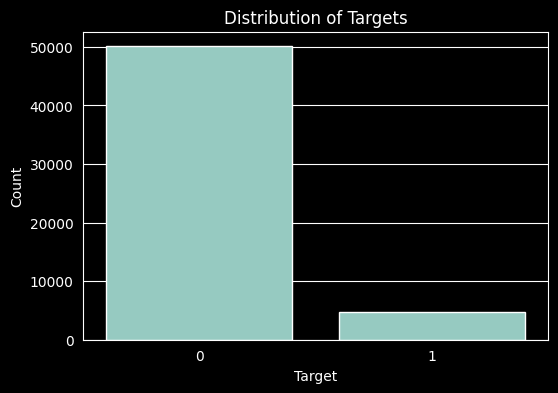

In [14]:
target_counts = hr_data['is_promoted'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(6, 4))

sns.barplot(x=target_counts.index, y=target_counts, ax=ax)

ax.set_xlabel('Target')
ax.set_ylabel('Count')
ax.set_title('Distribution of Targets')

plt.show()

In [15]:
X = hr_data.drop('is_promoted', axis=1)
y = hr_data['is_promoted']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

X_train.shape, X_test.shape

((38314, 11), (16421, 11))

In [17]:
lgbm_clf = lgb.LGBMClassifier(
    objective='binary',
    learning_rate=0.05,
    num_leaves=31,
    n_estimators=100,
    random_state=42,
    verbose=-1,
)

lgbm_clf.fit(X_train, y_train)

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,100
,subsample_for_bin,200000
,objective,'binary'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [18]:
def compute_metrics(clf):
    y_pred = clf.predict(X_test)
    y_pred_proba = clf.predict_proba(X_test)[:, 1]

    metrics = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1 Score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC Score": roc_auc_score(y_test, y_pred_proba),
    }

    print("Evaluation Metrics:")
    for name, value in metrics.items():
        print(f"{name}: {value:.4f}")

    return metrics

In [19]:
compute_metrics(lgbm_clf)

Evaluation Metrics:
Accuracy: 0.9406
Precision: 0.9568
Recall: 0.3167
F1 Score: 0.4758
ROC-AUC Score: 0.8257


{'Accuracy': 0.9405639120638207,
 'Precision': 0.9568034557235421,
 'Recall': 0.3166547533952823,
 'F1 Score': 0.4758324382384533,
 'ROC-AUC Score': 0.8257147320456087}

In [21]:
lgbm_clf = lgb.LGBMClassifier(
    objective='binary',
    learning_rate=0.05,
    num_leaves=31,
    max_bin=400,
    n_estimators=1000,
    random_state=42,
    verbose=-1,
)

lgbm_clf.fit(X_train, y_train)

compute_metrics(lgbm_clf)

Evaluation Metrics:
Accuracy: 0.9395
Precision: 0.8859
Recall: 0.3331
F1 Score: 0.4842
ROC-AUC Score: 0.8150


{'Accuracy': 0.9395286523354242,
 'Precision': 0.8859315589353612,
 'Recall': 0.3330950679056469,
 'F1 Score': 0.4841558441558442,
 'ROC-AUC Score': 0.8149825098076311}

In [23]:
lgbm_clf = lgb.LGBMClassifier(
    objective='binary',
    learning_rate=0.05,
    num_leaves=31,
    class_weight='balanced',
    n_estimators=500,
    random_state=42,
    verbose=-1,
)

lgbm_clf.fit(X_train, y_train)

compute_metrics(lgbm_clf)

Evaluation Metrics:
Accuracy: 0.8434
Precision: 0.2953
Recall: 0.6047
F1 Score: 0.3968
ROC-AUC Score: 0.8184


{'Accuracy': 0.8433712928567079,
 'Precision': 0.29528795811518327,
 'Recall': 0.6047176554681916,
 'F1 Score': 0.3968105065666041,
 'ROC-AUC Score': 0.8183637312879876}

In [24]:
X_train_es, X_val, y_train_es, y_val = train_test_split(
    X_train, y_train, test_size=0.30, random_state=42, stratify=y_train)

X_train_es.shape, X_val.shape

((26819, 11), (11495, 11))

In [27]:
lgbm_clf = lgb.LGBMClassifier(
    objective='binary',
    learning_rate=0.05,
    num_leaves=31,
    class_weight='balanced',
    n_estimators=3000,
    random_state=42,
    verbose=1,
)

lgbm_clf.fit(X_train, y_train, eval_metric='f1', eval_set=[(X_val, y_val)], callbacks=[lgb.early_stopping(5)])

compute_metrics(lgbm_clf)

[LightGBM] [Info] Number of positive: 3263, number of negative: 35051
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.181349 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 213
[LightGBM] [Info] Number of data points in the train set: 38314, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
Training until validation scores don't improve for 5 rounds
Did not meet early stopping. Best iteration is:
[3000]	valid_0's binary_logloss: 0.100851
Evaluation Metrics:
Accuracy: 0.9004
Precision: 0.4219
Recall: 0.4575
F1 Score: 0.4390
ROC-AUC Score: 0.7935


{'Accuracy': 0.9003714755496012,
 'Precision': 0.4218852999340804,
 'Recall': 0.45746962115796996,
 'F1 Score': 0.438957475994513,
 'ROC-AUC Score': 0.7935434272288182}

In [28]:
def compute_metrics_native(gbm, threshold=0.5):
    y_pred_proba = gbm.predict(X_test)
    y_pred = (y_pred_proba >= threshold).astype(int)

    metrics = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1 Score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC Score": roc_auc_score(y_test, y_pred_proba),
    }

    print("Evaluation Metrics:")
    for name, value in metrics.items():
        print(f"{name}: {value:.4f}")

    return metrics

In [29]:
lgb_train = lgb.Dataset(X_train_es, y_train_es)

lgb_val = lgb.Dataset(X_val, y_val, reference=lgb_train)

lgb_test = lgb.Dataset(X_test, y_test, reference=lgb_train)

In [31]:
params = {
    "boosting_type": "gbdt",
    "objective": "binary",
    "metric": "auc",
    "num_leaves": 31,
    "feature_fraction": 0.9,
    "bagging_fraction": 0.8,
    "is_unbalance": True,
    "random_state": 42,
    "verbose": 1,
}

gbm = lgb.train(
    params, lgb_train,
    num_boost_round=2000,
    valid_sets=[lgb_val],
    callbacks=[lgb.early_stopping(stopping_rounds=10)]
)

compute_metrics_native(gbm, 0.7)

[LightGBM] [Info] Number of positive: 2284, number of negative: 24535
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.175396 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 211
[LightGBM] [Info] Number of data points in the train set: 26819, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.085164 -> initscore=-2.374172
[LightGBM] [Info] Start training from score -2.374172
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[31]	valid_0's auc: 0.821592
Evaluation Metrics:
Accuracy: 0.9233
Precision: 0.5675
Recall: 0.4174
F1 Score: 0.4811
ROC-AUC Score: 0.8175


{'Accuracy': 0.9232689848364899,
 'Precision': 0.5675413022351797,
 'Recall': 0.4174410293066476,
 'F1 Score': 0.48105436573311366,
 'ROC-AUC Score': 0.817531475637019}

## GOSS (gradient-based one-side sampling)

In [33]:
params = {
    "boosting_type": "gbdt",
    'data_sample_strategy': 'goss',
    "objective": "binary",
    "metric": "auc",
    "num_leaves": 31,
    "feature_fraction": 0.9,
    "bagging_fraction": 0.8,
    "is_unbalance": True,
    "random_state": 42,
    "verbose": 1,
}

gbm = lgb.train(
    params, lgb_train,
    num_boost_round=2000,
    valid_sets=[lgb_val],
    callbacks=[lgb.early_stopping(stopping_rounds=10)]
)

compute_metrics_native(gbm)

[LightGBM] [Info] Number of positive: 2284, number of negative: 24535
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.031807 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 211
[LightGBM] [Info] Number of data points in the train set: 26819, number of used features: 11
[LightGBM] [Info] Using GOSS
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.085164 -> initscore=-2.374172
[LightGBM] [Info] Start training from score -2.374172
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[51]	valid_0's auc: 0.827534
Evaluation Metrics:
Accuracy: 0.8055
Precision: 0.2528
Recall: 0.6562
F1 Score: 0.3650
ROC-AUC Score: 0.8203


{'Accuracy': 0.80549296632361,
 'Precision': 0.2528229137978518,
 'Recall': 0.6561829878484632,
 'F1 Score': 0.3650099403578529,
 'ROC-AUC Score': 0.8202650408659626}

In [34]:
importance_split = gbm.feature_importance(importance_type='split')
importance_gain = gbm.feature_importance(importance_type='gain')

features = lgbm_clf.booster_.feature_name()

In [37]:
df_split_importance = pd.DataFrame({
    'Feature': features,
    'Split Importance': importance_split,
}).sort_values(by='Split Importance', ascending=False)

df_split_importance

,Feature,Split Importance
10,avg_training_score,391
6,age,258
1,region,240
8,length_of_service,159
0,department,148
7,previous_year_rating,125
2,education,45
3,gender,45
4,recruitment_channel,42
5,no_of_trainings,41


In [39]:
df_gain_importance = pd.DataFrame({
    'Feature': features,
    'Gain Importance': importance_gain,
}).sort_values(by='Gain Importance', ascending=False)

df_gain_importance

,Feature,Gain Importance
10,avg_training_score,51102.204594
7,previous_year_rating,24222.731823
0,department,19182.158479
1,region,17583.362829
6,age,11506.937201
8,length_of_service,6630.092902
9,awards_won?,6340.967269
5,no_of_trainings,2751.768774
3,gender,2134.840216
2,education,2046.713696


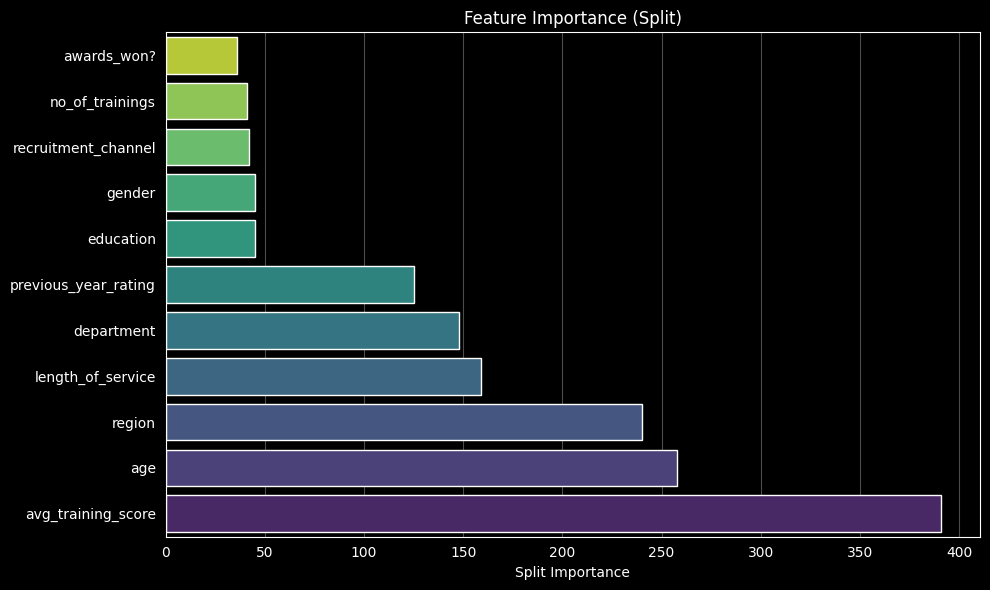

In [40]:
plot_data = df_split_importance.sort_values("Split Importance", ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=plot_data,
    x="Split Importance",
    y="Feature",
    hue="Feature",
    palette="viridis",
    dodge=False,
    legend=False,
    ax=ax
)

ax.set_title("Feature Importance (Split)")
ax.set_xlabel("Split Importance")
ax.set_ylabel("")
ax.invert_yaxis()
ax.grid(axis="x", alpha=0.3)

fig.tight_layout()
plt.show()

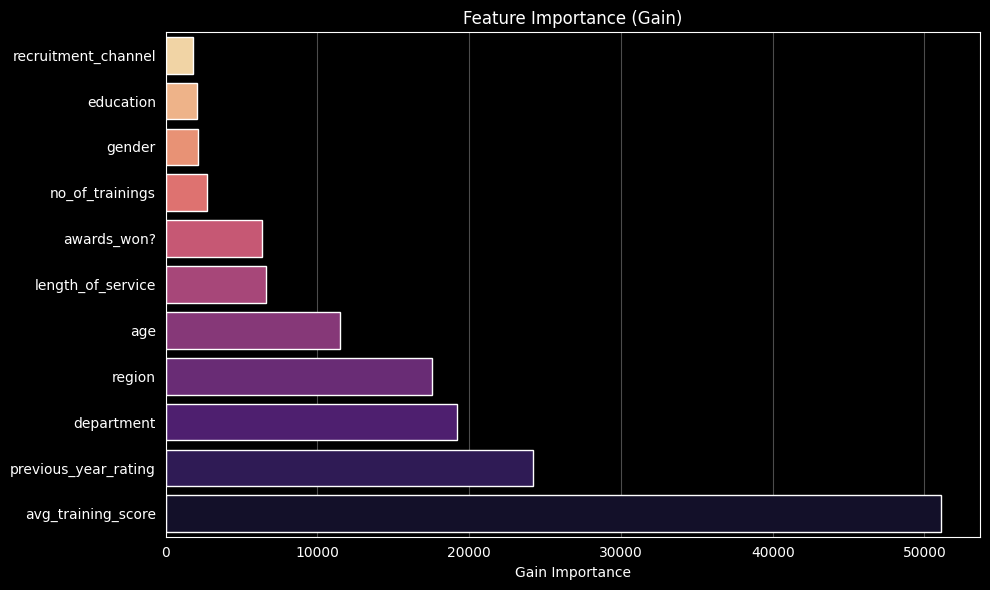

In [41]:
plot_data = df_gain_importance.sort_values("Gain Importance", ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=plot_data,
    x="Gain Importance",
    y="Feature",
    hue="Feature",
    palette="magma",
    dodge=False,
    legend=False,
    ax=ax
)

ax.set_title("Feature Importance (Gain)")
ax.set_xlabel("Gain Importance")
ax.set_ylabel("")
ax.invert_yaxis()
ax.grid(axis="x", alpha=0.3)

fig.tight_layout()
plt.show()